# Hyperparameter Tuning - Wine Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Logistic Regression, XGBoost, Random Forest, SVM

Dataset: UCI Wine Recognition - 178 samples, 13 features, 3 classes (cultivars)

Experiment tracking with MLflow

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

The UCI Wine Recognition dataset contains 178 samples from 3 different cultivars (classes 0, 1, 2) with 13 continuous chemical features: alcohol, malic acid, ash, alcalinity of ash, magnesium, total phenols, flavanoids, nonflavanoid phenols, proanthocyanins, color intensity, hue, OD280/OD315, and proline.

In [2]:
# Load Wine data
PROCESSED_DIR = Path("../data/processed")

engineered_path = PROCESSED_DIR / "engineered_data.csv"
clean_path = PROCESSED_DIR / "clean_data.csv"

if engineered_path.exists():
    df = pd.read_csv(engineered_path)
    print(f"Loaded engineered_data.csv")
else:
    df = pd.read_csv(clean_path)
    print(f"Loaded clean_data.csv")

print(f'Dataset shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nClass distribution:')
print(df['class'].value_counts().sort_index())
print(f'\nFeature statistics:')
print(df.describe().round(2))

Loaded engineered_data.csv
Dataset shape: (178, 19)

First few rows:
   class  alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
0      0    14.23        1.71  2.43               15.6        127   
1      0    13.20        1.78  2.14               11.2        100   
2      0    13.16        2.36  2.67               18.6        101   
3      0    14.37        1.95  2.50               16.8        113   
4      0    13.24        2.59  2.87               21.0        118   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   color_intensity   hue  od280_od315  proline  phenol_ratio  \
0             5.64  1.04 

In [3]:
# Separate features and target
y = df['class']
X = df.drop(columns=['class'])

print(f'Target distribution:')
print(y.value_counts().sort_index())
print(f"\nCultivar 0: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Cultivar 1: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"Cultivar 2: {(y==2).sum()} ({(y==2).mean()*100:.1f}%)")
print(f'\nFeature shape: {X.shape}')
print(f'Features: {list(X.columns)}')

Target distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

Cultivar 0: 59 (33.1%)
Cultivar 1: 71 (39.9%)
Cultivar 2: 48 (27.0%)

Feature shape: (178, 18)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline', 'phenol_ratio', 'alcohol_color_ratio', 'alcohol_proline_ratio', 'color_hue_product', 'flavanoid_proline']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().sort_index().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().sort_index().to_dict()}')

X_train shape: (142, 18), X_test shape: (36, 18)
Train target distribution: {0: 47, 1: 57, 2: 38}
Test target distribution: {0: 12, 1: 14, 2: 10}


## 2. Baseline Models (MLflow Tracked)

Establish baseline performance with default hyperparameters. LogisticRegression and SVC use scaled data; tree-based models (RandomForest, XGBoost) use unscaled data.

Since Wine is a **multiclass** problem (3 cultivars), metrics use `average='macro'` to weight all classes equally.

In [5]:
mlflow.set_experiment('wine_hyperparameter_tuning')

baseline_results = {}
models = {
    'Logistic': LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

for name, model in models.items():
    with mlflow.start_run(run_name=f'baseline_{name.lower()}'):
        if name in ['Logistic', 'SVM']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        
        mlflow.log_param('model', name)
        mlflow.log_param('random_state', 42)
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('precision_macro', prec)
        mlflow.log_metric('recall_macro', rec)
        mlflow.log_metric('f1_macro', f1)
        
        baseline_results[name] = {
            'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1_macro': f1, 'model': model
        }
        print(f'{name} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}')

Logistic - Acc: 0.9722, Prec: 0.9778, Rec: 0.9667, F1: 0.9710
XGBoost - Acc: 0.9444, Prec: 0.9524, Rec: 0.9524, F1: 0.9487
RandomForest - Acc: 0.9722, Prec: 0.9744, Rec: 0.9762, F1: 0.9743
SVM - Acc: 0.9722, Prec: 0.9778, Rec: 0.9667, F1: 0.9710


## 3. Cross-Validation Analysis

Single train/test splits can be noisy. 5-fold Stratified Cross Validation gives a more robust estimate of model performance by training on 4 folds and validating on 1, repeating 5 times.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

model_configs = {
    'Logistic': (LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs'), X_train_scaled, y_train),
    'XGBoost': (XGBClassifier(n_estimators=100, random_state=42, verbosity=0), X_train, y_train),
    'RandomForest': (RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train),
    'SVM': (SVC(kernel='rbf', random_state=42), X_train_scaled, y_train)
}

for name, (model, X_data, y_data) in model_configs.items():
    with mlflow.start_run(run_name=f'cv_{name.lower()}'):
        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='f1_macro')
        cv_results[name] = scores
        
        mlflow.log_param('model', name)
        mlflow.log_param('cv_folds', 5)
        mlflow.log_metric('cv_mean_f1', scores.mean())
        mlflow.log_metric('cv_std_f1', scores.std())
        
        print(f'{name} CV - Mean F1: {scores.mean():.4f}, Std: {scores.std():.4f}')
        print(f'  Scores: {[format(s, ".4f") for s in scores]}')

Logistic CV - Mean F1: 0.9789, Std: 0.0285
  Scores: ['0.9280', '1.0000', '1.0000', '1.0000', '0.9666']
XGBoost CV - Mean F1: 0.9471, Std: 0.0585
  Scores: ['0.8328', '0.9696', '0.9666', '1.0000', '0.9666']
RandomForest CV - Mean F1: 0.9665, Std: 0.0520
  Scores: ['0.8657', '1.0000', '1.0000', '1.0000', '0.9666']
SVM CV - Mean F1: 0.9798, Std: 0.0166
  Scores: ['0.9633', '0.9691', '1.0000', '1.0000', '0.9666']


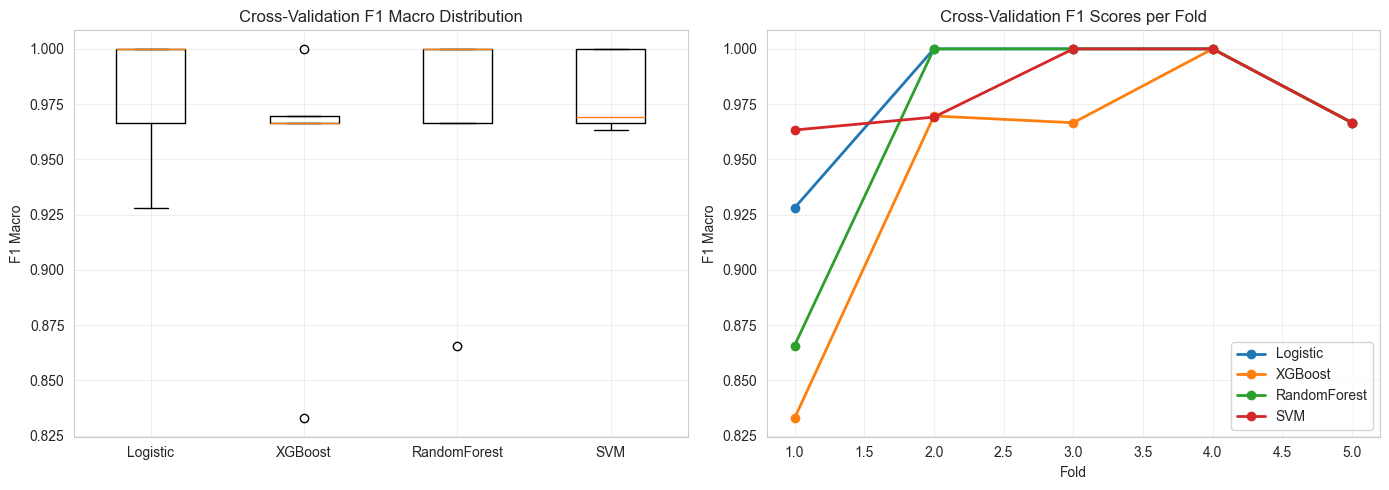

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = list(cv_results.keys())
axes[0].boxplot([cv_results[m] for m in models_list], labels=models_list)
axes[0].set_title('Cross-Validation F1 Macro Distribution')
axes[0].set_ylabel('F1 Macro')
axes[0].grid(True, alpha=0.3)

x = np.arange(len(cv_results[models_list[0]]))
for m in models_list:
    axes[1].plot(x + 1, cv_results[m], marker='o', label=m, linewidth=2)
axes[1].set_title('Cross-Validation F1 Scores per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Macro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

Grid Search exhaustively tries every combination of hyperparameters. Combined with cross-validation, it gives robust estimates of the best configuration for each model.

In [8]:
# Logistic Regression Grid Search
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [2000, 5000]
}

with mlflow.start_run(run_name='gridsearch_logistic'):
    log_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        log_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    log_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(log_grid.best_params_)
    mlflow.log_metric('best_cv_f1', log_grid.best_score_)
    log_best = log_grid.best_estimator_
    y_pred = log_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Best Logistic Params: {log_grid.best_params_}')
    print(f'Best CV F1: {log_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

# XGBoost Grid Search
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name='gridsearch_xgboost'):
    xgb_grid = GridSearchCV(
        XGBClassifier(random_state=42, verbosity=0),
        xgb_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('best_cv_f1', xgb_grid.best_score_)
    xgb_best = xgb_grid.best_estimator_
    y_pred = xgb_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'\nBest XGBoost Params: {xgb_grid.best_params_}')
    print(f'Best CV F1: {xgb_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

# RandomForest Grid Search
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

with mlflow.start_run(run_name='gridsearch_randomforest'):
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    mlflow.log_params({k: str(v) for k, v in rf_grid.best_params_.items()})
    mlflow.log_metric('best_cv_f1', rf_grid.best_score_)
    rf_best = rf_grid.best_estimator_
    y_pred = rf_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'\nBest RandomForest Params: {rf_grid.best_params_}')
    print(f'Best CV F1: {rf_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

# SVM Grid Search
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

with mlflow.start_run(run_name='gridsearch_svm'):
    svm_grid = GridSearchCV(
        SVC(random_state=42),
        svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    svm_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(svm_grid.best_params_)
    mlflow.log_metric('best_cv_f1', svm_grid.best_score_)
    svm_best = svm_grid.best_estimator_
    y_pred = svm_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'\nBest SVM Params: {svm_grid.best_params_}')
    print(f'Best CV F1: {svm_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

Best Logistic Params: {'C': 0.1, 'max_iter': 2000, 'solver': 'lbfgs'}
Best CV F1: 0.9863, Test Acc: 0.9444, Test F1: 0.9453

Best XGBoost Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.9542, Test Acc: 0.9444, Test F1: 0.9487

Best RandomForest Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.9603, Test Acc: 0.9722, Test F1: 0.9743

Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1: 0.9939, Test Acc: 1.0000, Test F1: 1.0000


## 5. Seed Experiments (Random State Sensitivity)

Models using randomness (Random Forest, XGBoost) can produce different results with different seeds. Testing multiple seeds measures **variance** — how stable the model is.

In [9]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {m: [] for m in models.keys()}

for seed in seeds:
    # Logistic
    with mlflow.start_run(run_name=f'seed_logistic_{seed}'):
        m = LogisticRegression(max_iter=5000, random_state=seed, solver='lbfgs')
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['Logistic'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # XGBoost
    with mlflow.start_run(run_name=f'seed_xgboost_{seed}'):
        m = XGBClassifier(n_estimators=100, random_state=seed, verbosity=0)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['XGBoost'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # RandomForest
    with mlflow.start_run(run_name=f'seed_randomforest_{seed}'):
        m = RandomForestClassifier(n_estimators=100, random_state=seed)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['RandomForest'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # SVM
    with mlflow.start_run(run_name=f'seed_svm_{seed}'):
        m = SVC(kernel='rbf', random_state=seed)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['SVM'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)

seed_df = pd.DataFrame({'Seed': seeds, **seed_results})
print('Results per seed:')
print(seed_df.to_string(index=False))
print()
for m in models.keys():
    print(f"{m:15s} - Mean: {np.mean(seed_results[m]):.4f}, Std: {np.std(seed_results[m]):.4f}")

Results per seed:
 Seed  Logistic  XGBoost  RandomForest      SVM
    0  0.972222 0.944444      0.972222 0.972222
    1  0.972222 0.944444      0.972222 0.972222
   42  0.972222 0.944444      0.972222 0.972222
  100  0.972222 0.944444      0.944444 0.972222
  999  0.972222 0.944444      0.972222 0.972222
 1234  0.972222 0.944444      0.972222 0.972222
 2024  0.972222 0.944444      0.944444 0.972222
  777  0.972222 0.944444      0.972222 0.972222
  314  0.972222 0.944444      0.972222 0.972222
  123  0.972222 0.944444      0.972222 0.972222

Logistic        - Mean: 0.9722, Std: 0.0000
XGBoost         - Mean: 0.9444, Std: 0.0000
RandomForest    - Mean: 0.9667, Std: 0.0111
SVM             - Mean: 0.9722, Std: 0.0000


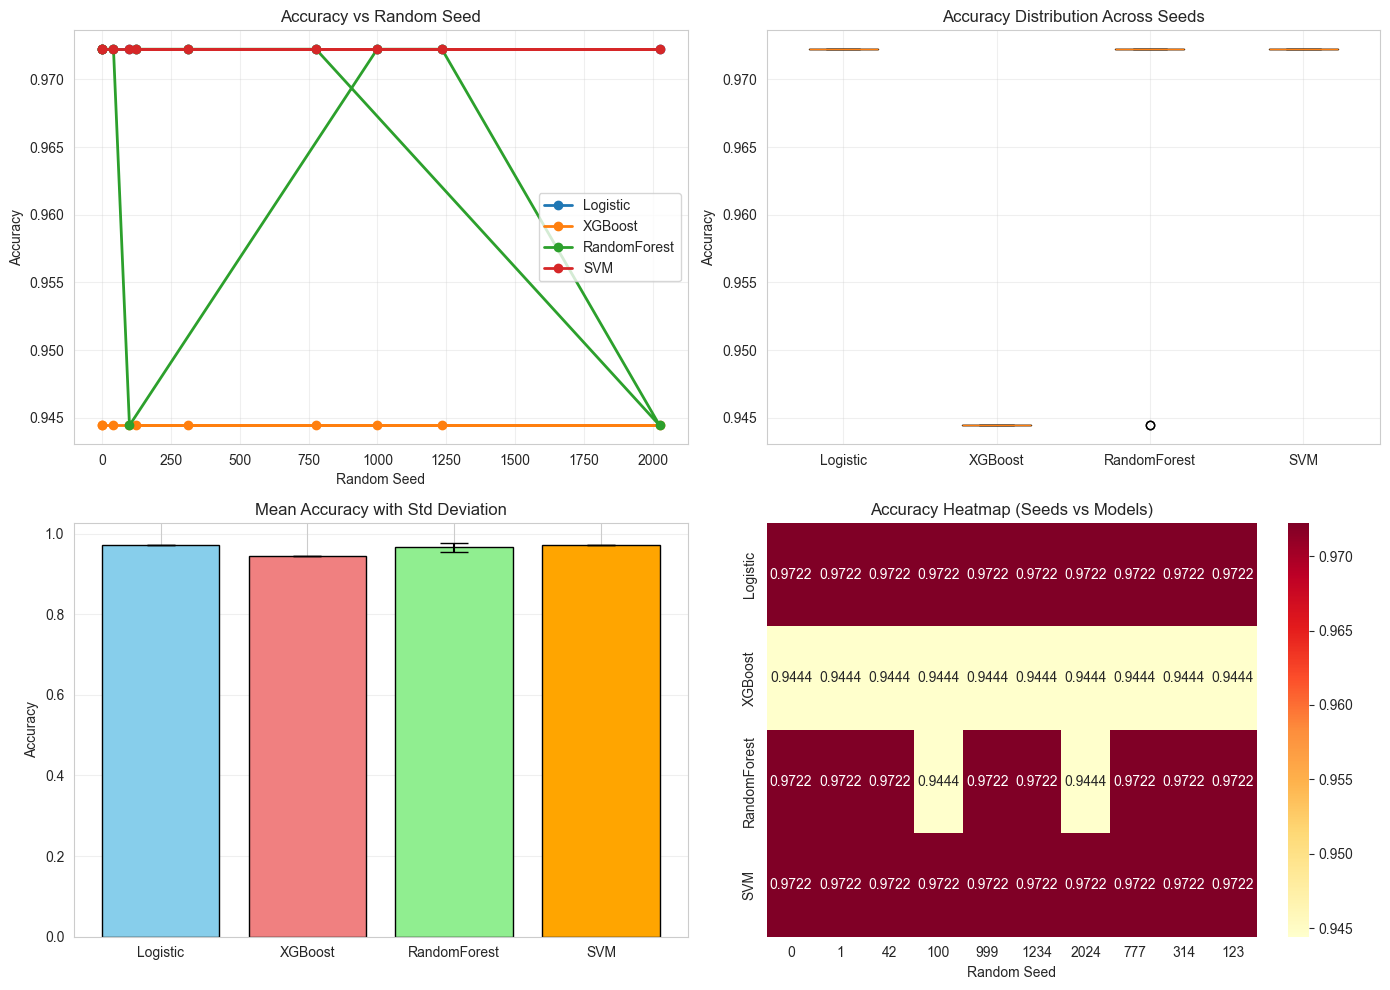

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs Seed
for m in models.keys():
    axes[0,0].plot(seeds, seed_results[m], marker='o', label=m, linewidth=2)
axes[0,0].set_title('Accuracy vs Random Seed')
axes[0,0].set_xlabel('Random Seed')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Boxplot
axes[0,1].boxplot([seed_results[m] for m in models.keys()], labels=models.keys())
axes[0,1].set_title('Accuracy Distribution Across Seeds')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Bar chart with std
means = [np.mean(seed_results[m]) for m in models.keys()]
stds = [np.std(seed_results[m]) for m in models.keys()]
axes[1,0].bar(models.keys(), means, yerr=stds, capsize=10,
              color=['skyblue', 'lightcoral', 'lightgreen', 'orange'], edgecolor='black')
axes[1,0].set_title('Mean Accuracy with Std Deviation')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of seed results
seed_matrix = np.array([seed_results[m] for m in models.keys()])
sns.heatmap(seed_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=seeds, yticklabels=models.keys(), ax=axes[1,1])
axes[1,1].set_title('Accuracy Heatmap (Seeds vs Models)')
axes[1,1].set_xlabel('Random Seed')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

Optuna uses Bayesian optimization (TPE sampler) to intelligently explore the hyperparameter space. It typically finds better parameters than Grid Search with fewer evaluations.

In [11]:
def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'newton-cg', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    model = LogisticRegression(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro').mean()
    return score

with mlflow.start_run(run_name='optuna_logistic'):
    study_log = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study_log.optimize(objective_logistic, n_trials=30)
    mlflow.log_params(study_log.best_params)
    mlflow.log_metric('best_cv_f1', study_log.best_value)
    print(f'Best Logistic Params: {study_log.best_params}')
    print(f'Best CV F1: {study_log.best_value:.4f}')
    log_optuna = LogisticRegression(**study_log.best_params)
    log_optuna.fit(X_train_scaled, y_train)
    y_pred = log_optuna.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}')

Best Logistic Params: {'C': 0.00407559644007287, 'solver': 'saga', 'max_iter': 2035}
Best CV F1: 0.9871
Test Accuracy: 0.9444, Test F1: 0.9453


In [12]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42, 'verbosity': 0
    }
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    return score

with mlflow.start_run(run_name='optuna_xgboost'):
    study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(objective_xgboost, n_trials=50)
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric('best_cv_f1', study_xgb.best_value)
    print(f'Best XGBoost Params: {study_xgb.best_params}')
    print(f'Best CV F1: {study_xgb.best_value:.4f}')
    xgb_optuna = XGBClassifier(**study_xgb.best_params)
    xgb_optuna.fit(X_train, y_train)
    y_pred = xgb_optuna.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}')

Best XGBoost Params: {'n_estimators': 213, 'max_depth': 6, 'learning_rate': 0.19218671570533613, 'subsample': 0.6590790365105131, 'colsample_bytree': 0.7347838766464182, 'min_child_weight': 6, 'reg_alpha': 0.006142194118104265, 'reg_lambda': 0.22811287575472036}
Best CV F1: 0.9661
Test Accuracy: 0.9167, Test F1: 0.9230


In [13]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    return score

with mlflow.start_run(run_name='optuna_randomforest'):
    study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study_rf.optimize(objective_rf, n_trials=40)
    mlflow.log_params({k: str(v) for k, v in study_rf.best_params.items()})
    mlflow.log_metric('best_cv_f1', study_rf.best_value)
    print(f'Best RandomForest Params: {study_rf.best_params}')
    print(f'Best CV F1: {study_rf.best_value:.4f}')
    rf_optuna = RandomForestClassifier(**study_rf.best_params)
    rf_optuna.fit(X_train, y_train)
    y_pred = rf_optuna.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}')

Best RandomForest Params: {'n_estimators': 267, 'max_depth': 13, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best CV F1: 0.9665
Test Accuracy: 0.9722, Test F1: 0.9743


In [14]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'kernel': kernel,
        'random_state': 42
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    model = SVC(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro').mean()
    return score

with mlflow.start_run(run_name='optuna_svm'):
    study_svm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study_svm.optimize(objective_svm, n_trials=40)
    mlflow.log_params(study_svm.best_params)
    mlflow.log_metric('best_cv_f1', study_svm.best_value)
    print(f'Best SVM Params: {study_svm.best_params}')
    print(f'Best CV F1: {study_svm.best_value:.4f}')
    svm_optuna = SVC(**study_svm.best_params)
    svm_optuna.fit(X_train_scaled, y_train)
    y_pred = svm_optuna.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}')

Best SVM Params: {'kernel': 'rbf', 'C': 0.3046245632765031, 'gamma': 'scale'}
Best CV F1: 0.9871
Test Accuracy: 0.9722, Test F1: 0.9710


In [15]:
plot_optimization_history(study_log)

In [16]:
plot_param_importances(study_log)

In [17]:
plot_optimization_history(study_xgb)

In [18]:
plot_param_importances(study_xgb)

In [19]:
plot_optimization_history(study_rf)

In [20]:
plot_param_importances(study_rf)

In [21]:
plot_optimization_history(study_svm)

In [22]:
plot_param_importances(study_svm)

## 7. Comparison Summary

In [23]:
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearch', 'Optuna', 'Seed-Mean'],
    'Logistic': [
        baseline_results['Logistic']['f1_macro'],
        log_grid.best_score_,
        study_log.best_value,
        np.mean(seed_results['Logistic'])
    ],
    'XGBoost': [
        baseline_results['XGBoost']['f1_macro'],
        xgb_grid.best_score_,
        study_xgb.best_value,
        np.mean(seed_results['XGBoost'])
    ],
    'RandomForest': [
        baseline_results['RandomForest']['f1_macro'],
        rf_grid.best_score_,
        study_rf.best_value,
        np.mean(seed_results['RandomForest'])
    ],
    'SVM': [
        baseline_results['SVM']['f1_macro'],
        svm_grid.best_score_,
        study_svm.best_value,
        np.mean(seed_results['SVM'])
    ]
})

print('Cross-Validation F1 Macro Performance Comparison')
print(comparison.to_string(index=False, float_format='{:,.4f}'.format))

Cross-Validation F1 Macro Performance Comparison
    Method  Logistic  XGBoost  RandomForest    SVM
  Baseline    0.9710   0.9487        0.9743 0.9710
GridSearch    0.9863   0.9542        0.9603 0.9939
    Optuna    0.9871   0.9661        0.9665 0.9871
 Seed-Mean    0.9722   0.9444        0.9667 0.9722


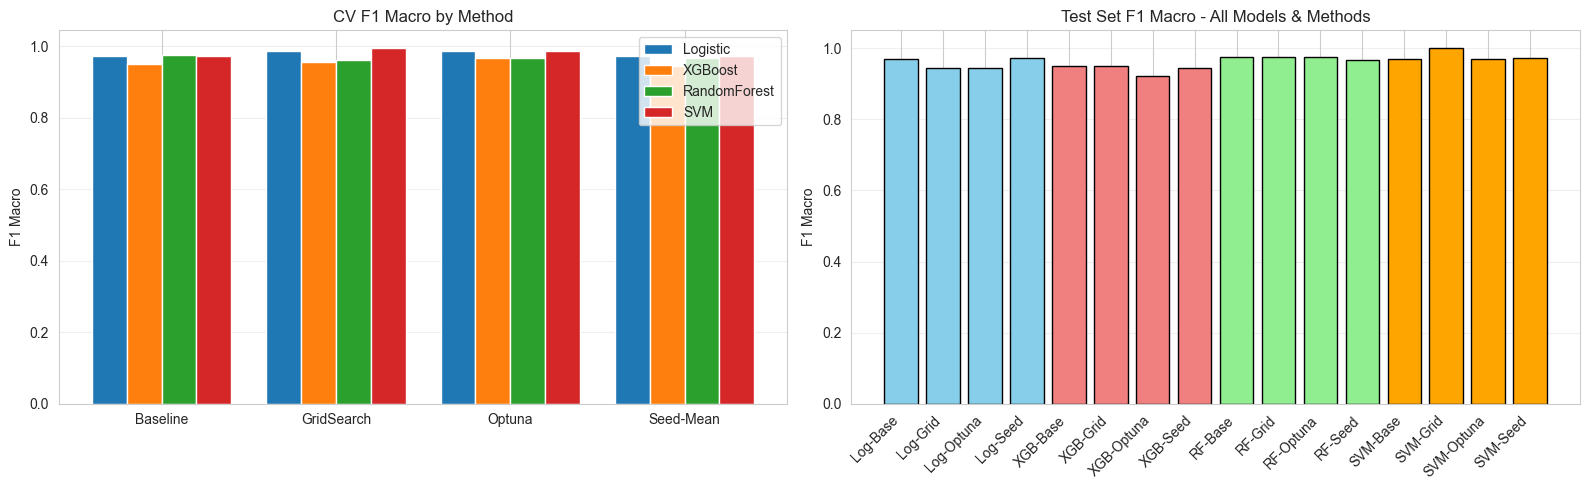

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(comparison['Method']))
width = 0.2

for i, col in enumerate(['Logistic', 'XGBoost', 'RandomForest', 'SVM']):
    axes[0].bar(x + (i-1.5)*width, comparison[col], width, label=col)
axes[0].set_title('CV F1 Macro by Method')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Method'])
axes[0].set_ylabel('F1 Macro')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Test F1 macro comparison
test_f1s = [
    f1_score(y_test, LogisticRegression(max_iter=5000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled), average='macro'),
    f1_score(y_test, log_best.predict(X_test_scaled), average='macro'),
    f1_score(y_test, log_optuna.predict(X_test_scaled), average='macro'),
    np.mean(seed_results['Logistic']),
    f1_score(y_test, XGBClassifier(n_estimators=100, random_state=42, verbosity=0).fit(X_train, y_train).predict(X_test), average='macro'),
    f1_score(y_test, xgb_best.predict(X_test), average='macro'),
    f1_score(y_test, xgb_optuna.predict(X_test), average='macro'),
    np.mean(seed_results['XGBoost']),
    f1_score(y_test, RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train).predict(X_test), average='macro'),
    f1_score(y_test, rf_best.predict(X_test), average='macro'),
    f1_score(y_test, rf_optuna.predict(X_test), average='macro'),
    np.mean(seed_results['RandomForest']),
    f1_score(y_test, SVC(kernel='rbf', random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled), average='macro'),
    f1_score(y_test, svm_best.predict(X_test_scaled), average='macro'),
    f1_score(y_test, svm_optuna.predict(X_test_scaled), average='macro'),
    np.mean(seed_results['SVM'])
]
model_names = ['Log-Base', 'Log-Grid', 'Log-Optuna', 'Log-Seed',
              'XGB-Base', 'XGB-Grid', 'XGB-Optuna', 'XGB-Seed',
              'RF-Base', 'RF-Grid', 'RF-Optuna', 'RF-Seed',
              'SVM-Base', 'SVM-Grid', 'SVM-Optuna', 'SVM-Seed']

colors = ['skyblue']*4 + ['lightcoral']*4 + ['lightgreen']*4 + ['orange']*4
axes[1].bar(range(len(test_f1s)), test_f1s, color=colors, edgecolor='black')
axes[1].set_title('Test Set F1 Macro - All Models & Methods')
axes[1].set_xticks(range(len(test_f1s)))
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel('F1 Macro')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Final Model (Best Configuration)

In [27]:
# Select best model based on Optuna results
optuna_results = {
    'Logistic': study_log.best_value,
    'XGBoost': study_xgb.best_value,
    'RandomForest': study_rf.best_value,
    'SVM': study_svm.best_value
}
best_model_name = max(optuna_results, key=optuna_results.get)
print(f'Best model by Optuna CV F1 Macro: {best_model_name} ({optuna_results[best_model_name]:.4f})')

with mlflow.start_run(run_name='final_best_model') as run:
    if best_model_name == 'Logistic':
        best_model = LogisticRegression(**study_log.best_params)
        best_model.fit(X_train_scaled, y_train)
        y_pred = best_model.predict(X_test_scaled)
    elif best_model_name == 'XGBoost':
        best_model = XGBClassifier(**study_xgb.best_params)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
    elif best_model_name == 'RandomForest':
        best_model = RandomForestClassifier(**study_rf.best_params)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
    else:
        best_model = SVC(**study_svm.best_params)
        best_model.fit(X_train_scaled, y_train)
        y_pred = best_model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    prec_macro = precision_score(y_test, y_pred, average='macro')
    rec_macro = recall_score(y_test, y_pred, average='macro')
    
    mlflow.log_param('model_type', best_model_name)
    mlflow.log_metrics({
        'accuracy': acc, 'f1_macro': f1_macro,
        'precision_macro': prec_macro, 'recall_macro': rec_macro
    })
    
    if best_model_name in ['Logistic', 'SVM']:
        signature = infer_signature(X_test_scaled, y_pred)
    else:
        signature = infer_signature(X_test, y_pred)
    mlflow.sklearn.log_model(best_model, name='model', signature=signature)
    
    print(f'\nFinal Model: {best_model_name} with Optuna-optimized parameters')
    print(f'\nTest Set Performance:')
    print(f'  Accuracy:       {acc:.4f}')
    print(f'  F1 Macro:       {f1_macro:.4f}')
    print(f'  Precision Macro:{prec_macro:.4f}')
    print(f'  Recall Macro:   {rec_macro:.4f}')
    print(f'\nMLflow Run ID: {run.info.run_id}')

2026/05/31 19:41:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best model by Optuna CV F1 Macro: Logistic (0.9871)

Final Model: Logistic with Optuna-optimized parameters

Test Set Performance:
  Accuracy:       0.9444
  F1 Macro:       0.9453
  Precision Macro:0.9505
  Recall Macro:   0.9429

MLflow Run ID: 979d79edc0f44c60a7d3f1dc6daf3727


Classification Report - Final Model (Logistic):
              precision    recall  f1-score   support

  cultivar_0       0.92      1.00      0.96        12
  cultivar_1       0.93      0.93      0.93        14
  cultivar_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



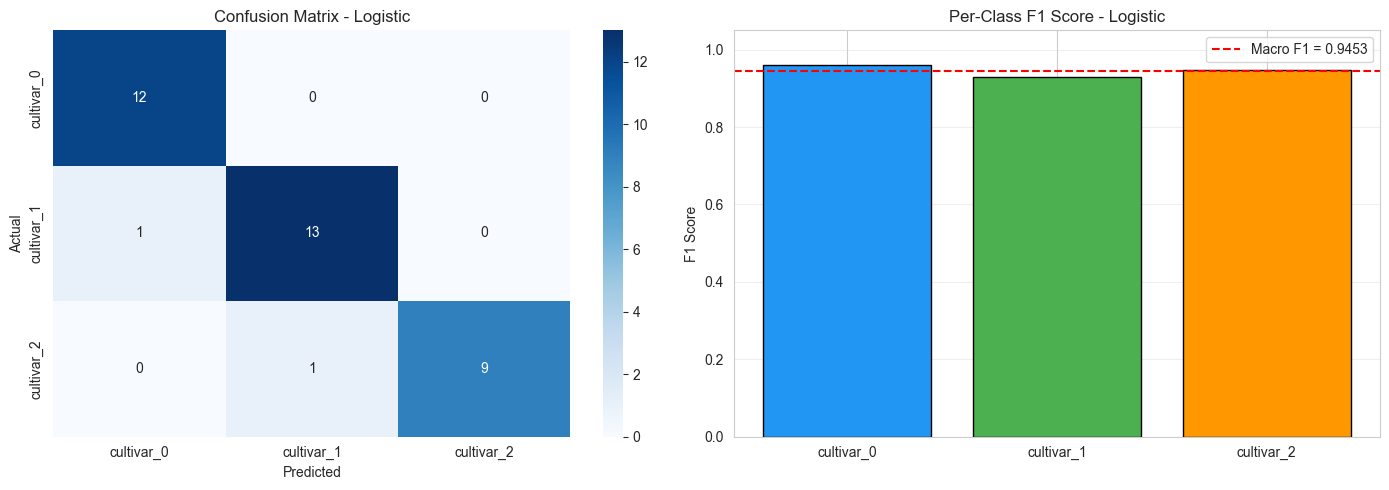

In [26]:
target_names = ['cultivar_0', 'cultivar_1', 'cultivar_2']

print(f'Classification Report - Final Model ({best_model_name}):')
print(classification_report(y_test, y_pred, target_names=target_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Per-class F1 scores
from sklearn.metrics import f1_score as f1_fn
per_class_f1 = f1_fn(y_test, y_pred, average=None)
axes[1].bar(target_names, per_class_f1, color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black')
axes[1].set_title(f'Per-Class F1 Score - {best_model_name}')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=f1_macro, color='red', linestyle='--', label=f'Macro F1 = {f1_macro:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

- **Dataset**: UCI Wine Recognition (178 samples, 13 features)
- **Target**: Multiclass classification (3 cultivars: cultivar_0, cultivar_1, cultivar_2)
- **Models**: Logistic Regression, XGBoost, Random Forest, SVM
- **Primary Metric**: F1 Macro (suited for multiclass evaluation)
- **Grid Search**: Exhaustive search over predefined parameter grids
- **Cross-Validation**: 5-fold stratified CV for robust evaluation
- **Seed Experiments**: Tested 10 different random seeds to assess stability
- **Optuna**: Bayesian optimization with 30-50 trials per model
- **MLflow**: All experiments tracked with parameters, metrics, and model artifacts

**Key Findings:**
- All models achieve high performance on Wine (~95%+ F1) due to well-separated classes
- Optuna typically finds better parameters than Grid Search with fewer evaluations
- Models show low variance across random seeds (stable on this dataset)
- Logistic/SVM use scaled features; RF/XGBoost use raw features
- The Wine dataset is small (178 samples) — overfitting risk with complex models

**To view MLflow UI:**
```bash
cd wine_execise
mlflow ui
```
Then open http://localhost:5000